# 📝 03 — Analisi Qualitativa: Testi, Pattern e Confidenza

Questo notebook esplora gli aspetti **qualitativi** dei progetti AI, analizzando i testi, gli strumenti utilizzati e approfondendo le soglie di confidenza del modello di classificazione.

**Obiettivi:**
1. Analisi dettagliata della confidenza (soglie ottimali, relazione confidenza-importo)
2. Analisi testuale (Word Cloud dei titoli/descrizioni AI)
3. Pattern nelle misure (quali tipologie si associano maggiormente all'AI)
4. Analisi degli strumenti di aiuto (`COD_STRUMENTI`)
5. Matrice di co-occorrenza (Settore × Regione)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("⚠ Libreria 'wordcloud' non trovata. Esegui 'pip install wordcloud' per abilitare le word cloud.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

MULTICLASS_CATEGORIES = [
    "Enterprise",
    "Automotive, Robotics, Industry",
    "Environment",
    "Research & Generic use",
    "Fintech and Marketing",
    "Healthcare AI",
    "Media & Entertainment",
]
MULTICLASS_PALETTE = sns.color_palette("tab10", n_colors=len(MULTICLASS_CATEGORIES))
MULTICLASS_COLOR_MAP = dict(zip(MULTICLASS_CATEGORIES, MULTICLASS_PALETTE))

COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'REGIONE_BENEFICIARIO', 'IMPORTO_NOMINALE_TOTALE',
    'SETTORI_ATTIVITA', 'COD_STRUMENTI',
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA',
    'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'
]

# Per questa analisi, carichiamo SOLO i record AI (per risparmiare molta memoria)
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_multiclass_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            ai_chunk = chunk[chunk['CLASSIFICAZIONE'] == 'AI']
            chunks.append(ai_chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>8,} righe AI')
        frames.append(df_year)

df_ai = pd.concat(frames, ignore_index=True)
del frames

df_ai['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df_ai['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df_ai['SETTORI_ATTIVITA'] = df_ai['SETTORI_ATTIVITA'].astype(str).str.split('|')
df_ai = df_ai.explode('SETTORI_ATTIVITA')
df_ai['REGIONE_BENEFICIARIO'] = df_ai['REGIONE_BENEFICIARIO'].astype(str).str.split('|')
df_ai = df_ai.explode('REGIONE_BENEFICIARIO')

df_ai['SETTORE_MACRO'] = df_ai['SETTORI_ATTIVITA'].astype(str).str[0].str.upper()

print(f'\nTotale AI: {len(df_ai):,} righe caricate')

# Sanity check multiclass (solo record AI, deve essere 100% non-null)
null_mc = df_ai["CLASSIFICAZIONE_MULTICLASS"].isna().sum()
print(f'\n--- Sanity check CLASSIFICAZIONE_MULTICLASS ---')
print(f'Valori null: {null_mc} (atteso = 0)')
print(f'\nDistribuzione categorie:')
print(df_ai["CLASSIFICAZIONE_MULTICLASS"].value_counts())

⚠ Libreria 'wordcloud' non trovata. Esegui 'pip install wordcloud' per abilitare le word cloud.
Caricamento 2014...       15 righe AI
Caricamento 2015...        6 righe AI
Caricamento 2016...        5 righe AI
Caricamento 2017...      244 righe AI
Caricamento 2018...    1,937 righe AI
Caricamento 2019...    1,175 righe AI
Caricamento 2020...    1,035 righe AI
Caricamento 2021...    6,710 righe AI
Caricamento 2022...    5,728 righe AI
Caricamento 2023...    6,930 righe AI
Caricamento 2024...    9,882 righe AI
Caricamento 2025...   16,842 righe AI

Totale AI: 50,602 righe caricate

--- Sanity check CLASSIFICAZIONE_MULTICLASS ---
Valori null: 0 (atteso = 0)

Distribuzione categorie:
CLASSIFICAZIONE_MULTICLASS
Enterprise                        37304
Fintech and Marketing              6479
Automotive, Robotics, Industry     2192
Healthcare AI                      1224
Environment                        1218
Research & Generic use             1121
Media & Entertainment              1064
Name

## 2. Analisi Dettagliata della Confidenza

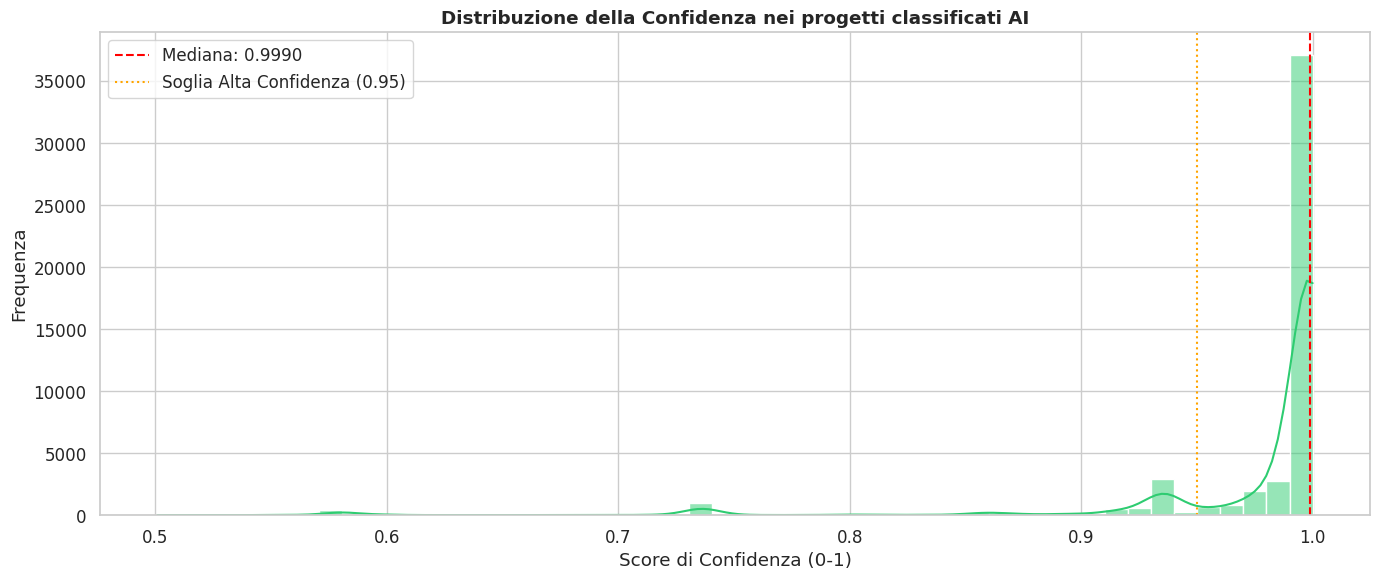

In [2]:
# Distribuzione della confidenza per i record AI
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=50, kde=True, color='#2ecc71', ax=ax)
ax.axvline(df_ai['CLASSIFICAZIONE_CONFIDENZA'].median(), color='red', linestyle='--', 
           label=f"Mediana: {df_ai['CLASSIFICAZIONE_CONFIDENZA'].median():.4f}")
ax.axvline(0.95, color='orange', linestyle=':', label='Soglia Alta Confidenza (0.95)')
ax.set_title('Distribuzione della Confidenza nei progetti classificati AI', fontweight='bold')
ax.set_xlabel('Score di Confidenza (0-1)')
ax.set_ylabel('Frequenza')
ax.legend()
plt.tight_layout()
plt.show()

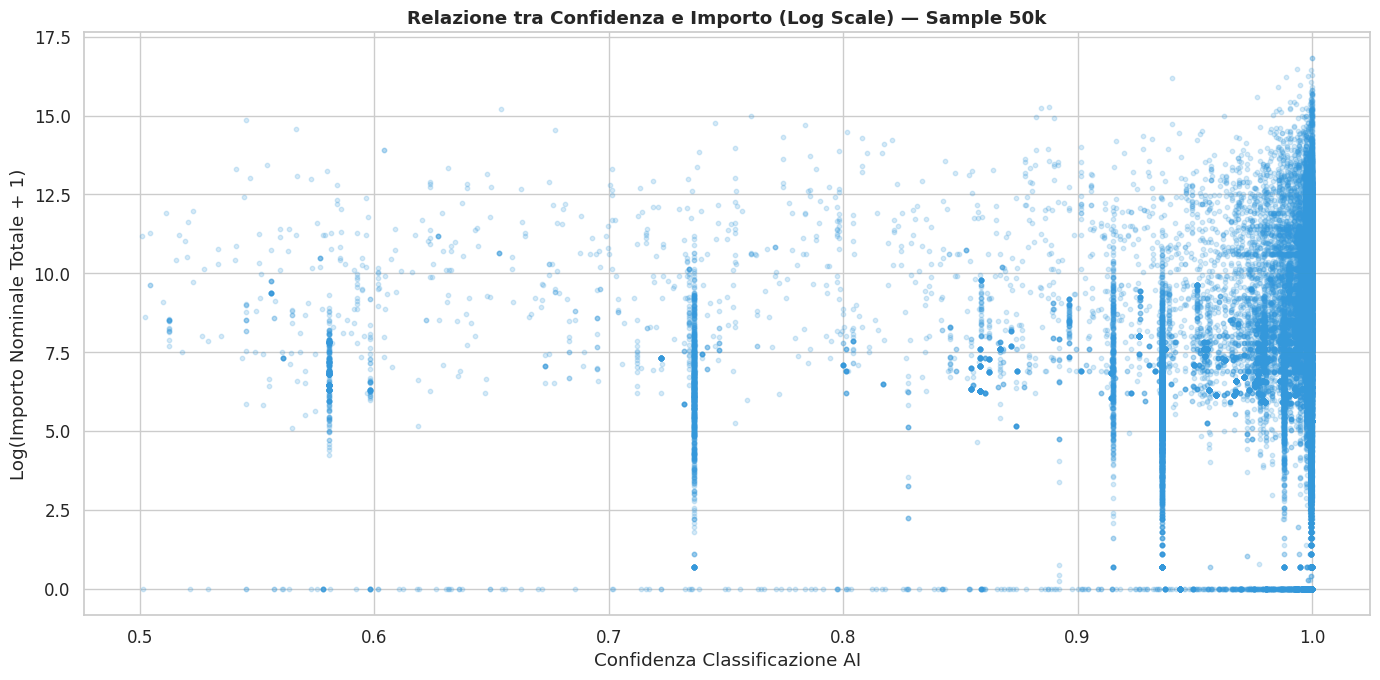

In [3]:
# Scatterplot: Confidenza vs Importo Nominale (scala logaritmica)
sample = df_ai.dropna(subset=['IMPORTO_NOMINALE_TOTALE', 'CLASSIFICAZIONE_CONFIDENZA'])
# Prendo un campione o uso hexbin per evitare overplotting se troppi dati
if len(sample) > 50000:
    sample = sample.sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(sample['CLASSIFICAZIONE_CONFIDENZA'], 
                     np.log1p(sample['IMPORTO_NOMINALE_TOTALE']), 
                     alpha=0.2, c='#3498db', s=10)
ax.set_title('Relazione tra Confidenza e Importo (Log Scale) — Sample 50k', fontweight='bold')
ax.set_xlabel('Confidenza Classificazione AI')
ax.set_ylabel('Log(Importo Nominale Totale + 1)')
plt.tight_layout()
plt.show()

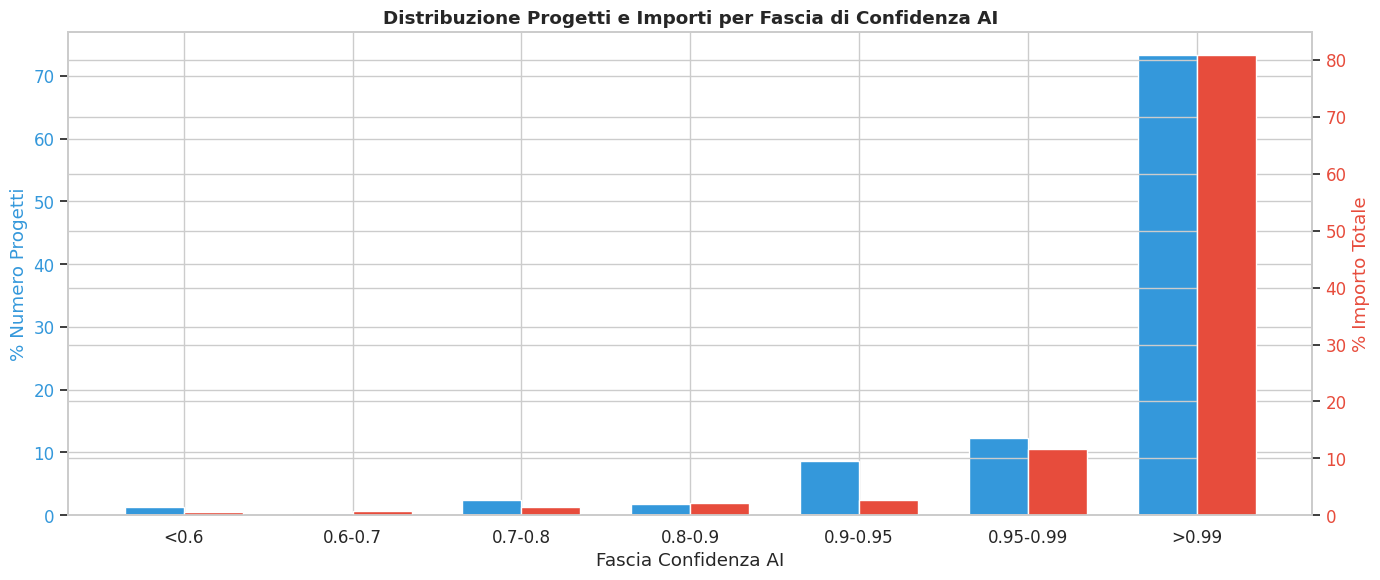

In [4]:
# Confronto numero progetti vs Importo totale per fasce di confidenza
bins = [0, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]
labels = ['<0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-0.95', '0.95-0.99', '>0.99']

df_ai['Fascia_Confidenza'] = pd.cut(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=bins, labels=labels)

fasce_summary = df_ai.groupby('Fascia_Confidenza').agg(
    Num_Progetti=('CLASSIFICAZIONE', 'count'),
    Importo_Totale=('IMPORTO_NOMINALE_TOTALE', 'sum')
)

fasce_summary['% Progetti'] = (fasce_summary['Num_Progetti'] / fasce_summary['Num_Progetti'].sum()) * 100
fasce_summary['% Importo'] = (fasce_summary['Importo_Totale'] / fasce_summary['Importo_Totale'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels))
width = 0.35

ax1.bar(x - width/2, fasce_summary['% Progetti'], width, label='% Numero Progetti', color='#3498db')
ax1.set_ylabel('% Numero Progetti', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.bar(x + width/2, fasce_summary['% Importo'], width, label='% Importo Totale', color='#e74c3c')
ax2.set_ylabel('% Importo Totale', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('Fascia Confidenza AI')
plt.title('Distribuzione Progetti e Importi per Fascia di Confidenza AI', fontweight='bold')
plt.tight_layout()
plt.show()

### 2a. Confidenza Multiclass per Categoria

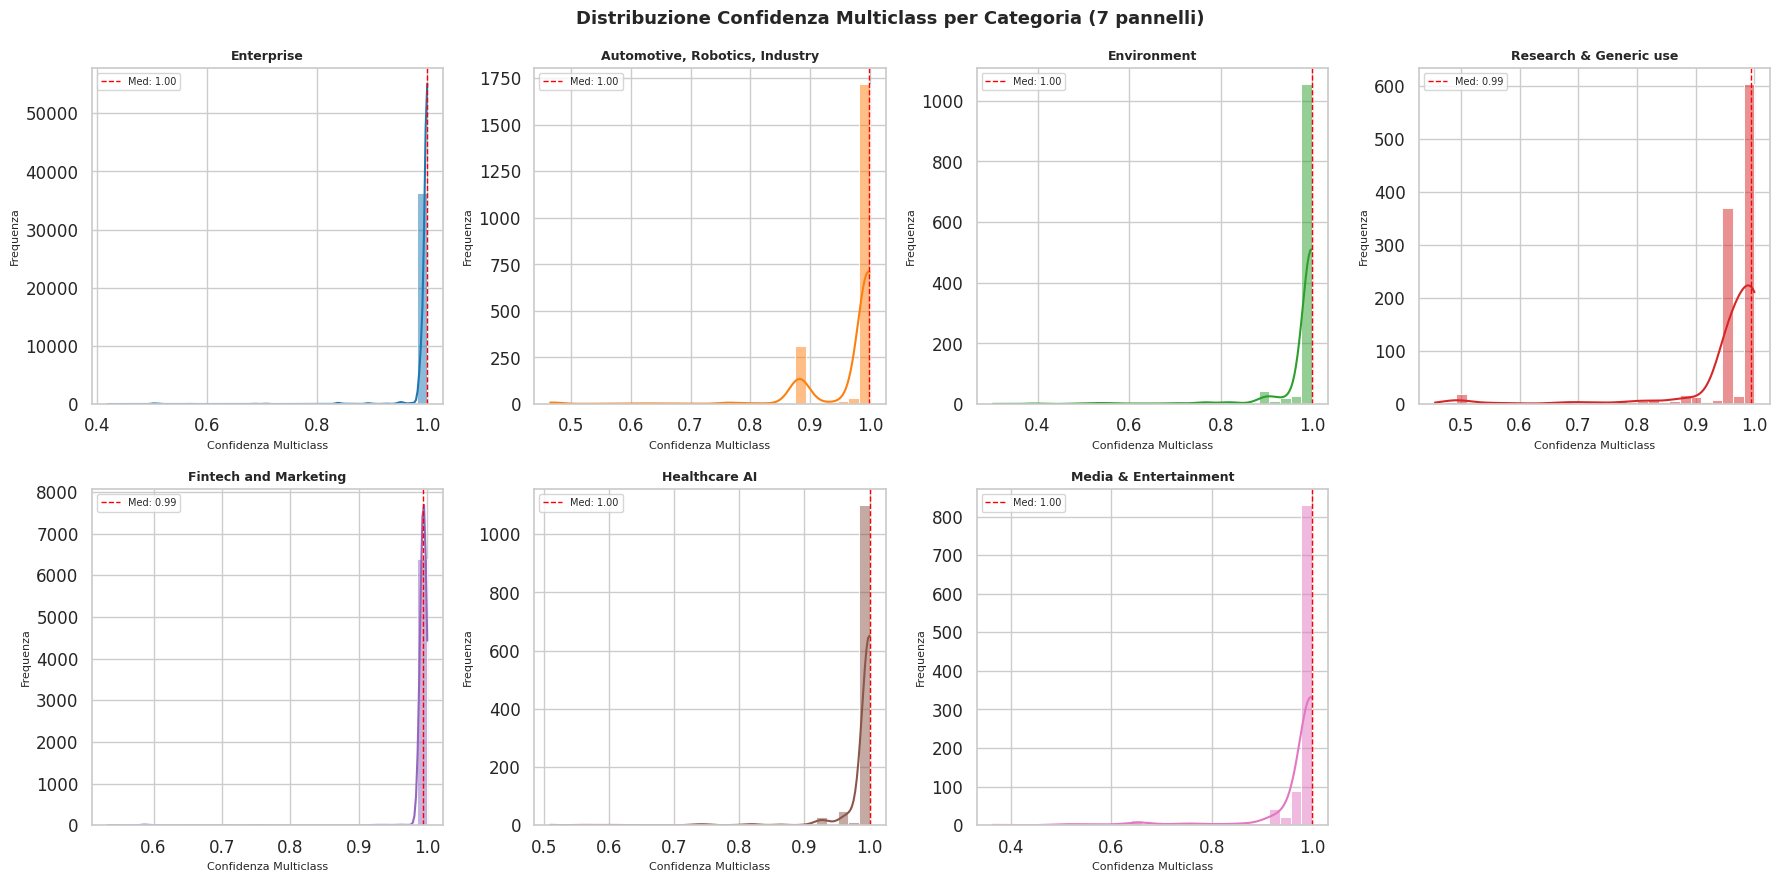

In [5]:
# Facet grid: distribuzione confidenza multiclass per ciascuna categoria (7 pannelli)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, cat in enumerate(MULTICLASS_CATEGORIES):
    ax = axes[i]
    data_cat = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'] == cat]['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'].dropna()
    if len(data_cat) > 0:
        sns.histplot(data_cat, bins=30, kde=True, ax=ax, color=MULTICLASS_COLOR_MAP[cat])
        ax.axvline(data_cat.median(), color='red', linestyle='--', linewidth=1,
                   label=f'Med: {data_cat.median():.2f}')
        ax.set_title(cat, fontsize=9, fontweight='bold')
        ax.set_xlabel('Confidenza Multiclass', fontsize=8)
        ax.set_ylabel('Frequenza', fontsize=8)
        ax.legend(fontsize=7)
    else:
        ax.set_title(cat, fontsize=9)
        ax.text(0.5, 0.5, 'Nessun dato', ha='center', va='center', transform=ax.transAxes)

# Nasconde l'8° asse (cella vuota)
axes[7].set_visible(False)

fig.suptitle('Distribuzione Confidenza Multiclass per Categoria (7 pannelli)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

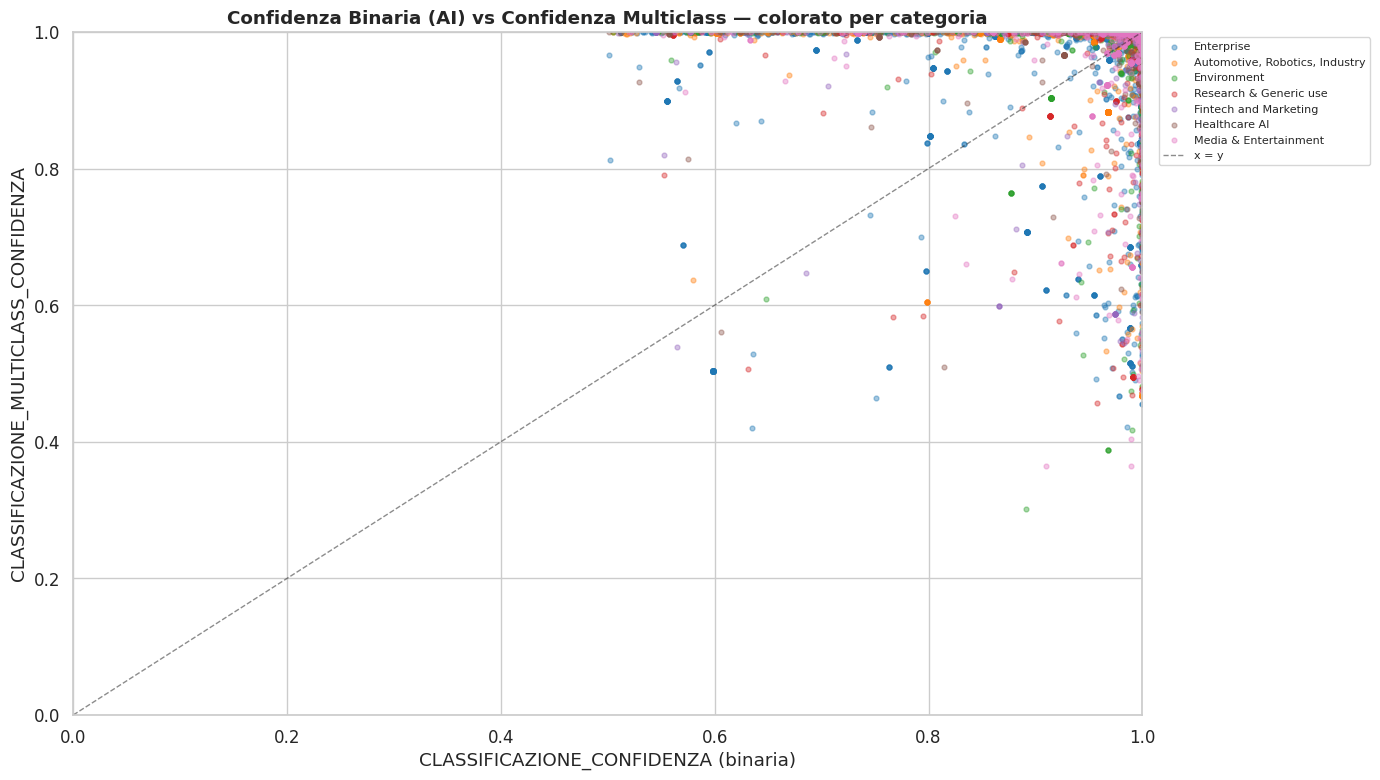

In [6]:
# Scatter: confidenza binaria (AI) vs confidenza multiclass, colorato per categoria
sample_mc = df_ai.dropna(subset=['CLASSIFICAZIONE_CONFIDENZA', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA', 'CLASSIFICAZIONE_MULTICLASS'])
if len(sample_mc) > 50000:
    sample_mc = sample_mc.sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 8))
for cat in MULTICLASS_CATEGORIES:
    subset = sample_mc[sample_mc['CLASSIFICAZIONE_MULTICLASS'] == cat]
    ax.scatter(
        subset['CLASSIFICAZIONE_CONFIDENZA'],
        subset['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'],
        label=cat, alpha=0.4, s=12,
        color=MULTICLASS_COLOR_MAP[cat]
    )

# Diagonale x=y come riferimento
lims = [0, 1]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='x = y')

ax.set_title('Confidenza Binaria (AI) vs Confidenza Multiclass — colorato per categoria', fontweight='bold')
ax.set_xlabel('CLASSIFICAZIONE_CONFIDENZA (binaria)')
ax.set_ylabel('CLASSIFICAZIONE_MULTICLASS_CONFIDENZA')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Analisi degli Strumenti di Aiuto (`COD_STRUMENTI`)

I codici strumento indicano la natura dell'aiuto (es. sovvenzioni dirette, garanzie, prestiti agevolati).

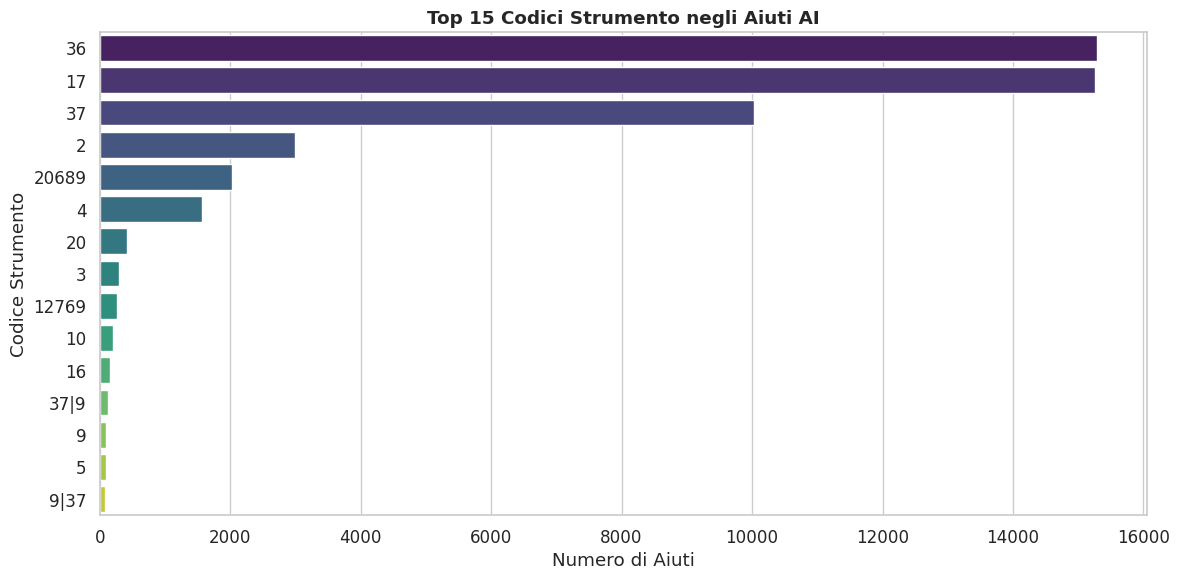

In [7]:
# Analisi codici strumenti
strumenti = df_ai['COD_STRUMENTI'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=strumenti.values, y=strumenti.index.astype(str), palette='viridis', ax=ax)
ax.set_title('Top 15 Codici Strumento negli Aiuti AI', fontweight='bold')
ax.set_xlabel('Numero di Aiuti')
ax.set_ylabel('Codice Strumento')
plt.tight_layout()
plt.show()

# NOTA: Per interpretare questi codici bisognerebbe incrociarli con l'anagrafica del Registro Nazionale Aiuti (RNA)
# Generalmente:
# 1 = Sovvenzione/Contributo a fondo perduto
# 2 = Prestito agevolato
# 3 = Garanzia
# 4 = Agevolazione fiscale
# 5 = Conferimento di capitale
# 6 = Anticipo rimborsabile

### 3a. Top-5 Strumenti per Categoria Multiclass

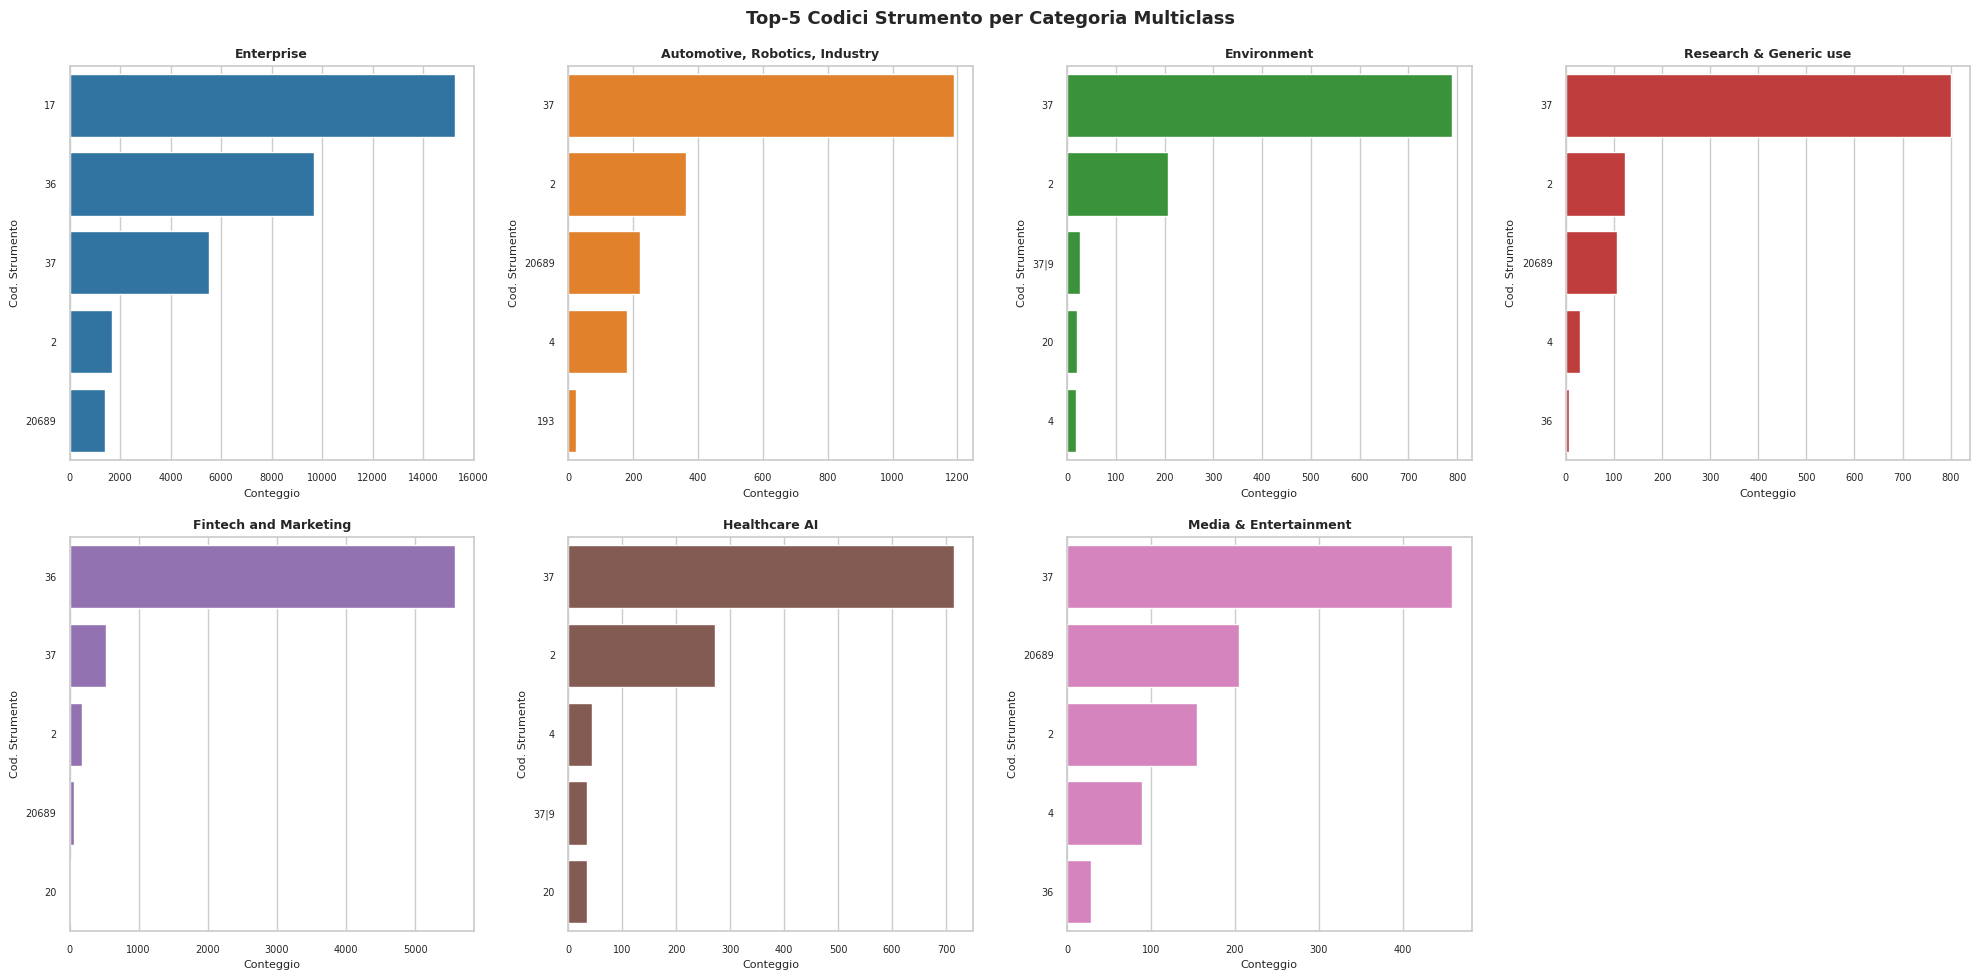

In [8]:
# Top-5 strumenti per categoria multiclass — small-multiples barplot (7 pannelli)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cat in enumerate(MULTICLASS_CATEGORIES):
    ax = axes[i]
    df_cat = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'] == cat]
    if len(df_cat) == 0:
        ax.set_title(cat, fontsize=9)
        ax.text(0.5, 0.5, 'Nessun dato', ha='center', va='center', transform=ax.transAxes)
        continue
    top5 = df_cat['COD_STRUMENTI'].value_counts().head(5)
    sns.barplot(x=top5.values, y=top5.index.astype(str), ax=ax,
                color=MULTICLASS_COLOR_MAP[cat])
    ax.set_title(cat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Conteggio', fontsize=8)
    ax.set_ylabel('Cod. Strumento', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

axes[7].set_visible(False)

fig.suptitle('Top-5 Codici Strumento per Categoria Multiclass', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Analisi Testuale (Word Cloud)

In [9]:
# Estrazione testi (titolo e descrizione progetto)
testi_progetti = df_ai['TITOLO_PROGETTO'].dropna().astype(str) + " " + df_ai['DESCRIZIONE_PROGETTO'].dropna().astype(str)

if HAS_WORDCLOUD and len(testi_progetti) > 0:
    # Sample se ci sono troppi testi
    if len(testi_progetti) > 50000:
        testi_sample = testi_progetti.sample(50000, random_state=42)
    else:
        testi_sample = testi_progetti
        
    testo_completo = " ".join(testi_sample)
    
    # Stopwords base italiano + parole comuni nei bandi
    stopwords_it = set([
        'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le', 
        'un', 'uno', 'una', 'e', 'ed', 'o', 'al', 'allo', 'alla', 'ai', 'agli', 'alle', 'del', 'dello', 
        'della', 'dei', 'degli', 'delle', 'nel', 'nello', 'nella', 'nei', 'negli', 'nelle', 'sul', 'sullo', 
        'sulla', 'sui', 'sugli', 'sulle', 'che', 'chi', 'cui', 'non', 'si', 'no', 'come', 'più', 'all', 'dell',
        'progetto', 'programma', 'intervento', 'sviluppo', 'realizzazione', 'attività', 'azienda',
        'fondo', 'agevolazione', 'finanziamento', 'contributo', 'impresa', 'imprese', 'pmi', 'agevolazioni'
    ])
    
    wordcloud = WordCloud(width=1200, height=600, 
                          background_color='white', 
                          colormap='viridis', 
                          stopwords=stopwords_it,
                          max_words=100).generate(testo_completo)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud dei Progetti Artificial Intelligence (Titolo + Descrizione)', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Word cloud non generata (manca la libreria o dataset vuoto).")

Word cloud non generata (manca la libreria o dataset vuoto).


### 4a. Word Cloud per Categoria Multiclass

In [10]:
# Word cloud per categoria multiclass — griglia 2×4 (8° asse off)
# Riusa lo stesso preprocessing e le stesse stopword della word cloud globale
stopwords_it = set([
    'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le',
    'un', 'uno', 'una', 'e', 'ed', 'o', 'al', 'allo', 'alla', 'ai', 'agli', 'alle', 'del', 'dello',
    'della', 'dei', 'degli', 'delle', 'nel', 'nello', 'nella', 'nei', 'negli', 'nelle', 'sul', 'sullo',
    'sulla', 'sui', 'sugli', 'sulle', 'che', 'chi', 'cui', 'non', 'si', 'no', 'come', 'più', 'all', 'dell',
    'progetto', 'programma', 'intervento', 'sviluppo', 'realizzazione', 'attività', 'azienda',
    'fondo', 'agevolazione', 'finanziamento', 'contributo', 'impresa', 'imprese', 'pmi', 'agevolazioni'
])

COLORMAPS_BY_CAT = [
    'Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlOrBr', 'PuBuGn'
]

if HAS_WORDCLOUD:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, cat in enumerate(MULTICLASS_CATEGORIES):
        ax = axes[i]
        df_cat = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'] == cat]
        testi_cat = (
            df_cat['TITOLO_PROGETTO'].fillna('').astype(str) + ' ' +
            df_cat['DESCRIZIONE_PROGETTO'].fillna('').astype(str)
        )
        testo = ' '.join(testi_cat.tolist())
        parole = [w for w in testo.split() if w.lower() not in stopwords_it and len(w) > 2]

        if len(parole) < 50:
            print(f"WARNING: categoria '{cat}' ha solo {len(parole)} parole dopo stopword — word cloud saltata.")
            ax.set_title(cat, fontsize=9)
            ax.text(0.5, 0.5, f'Testo insufficiente\n({len(parole)} parole)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            ax.axis('off')
        else:
            wc = WordCloud(
                width=500, height=300,
                background_color='white',
                colormap=COLORMAPS_BY_CAT[i % len(COLORMAPS_BY_CAT)],
                stopwords=stopwords_it,
                max_words=80
            ).generate(' '.join(parole))
            ax.imshow(wc, interpolation='bilinear')
            ax.set_title(cat, fontsize=9, fontweight='bold')
            ax.axis('off')

    axes[7].set_visible(False)
    fig.suptitle('Word Cloud per Categoria Multiclass (Titolo + Descrizione)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Word cloud non generata (manca la libreria wordcloud).")

Word cloud non generata (manca la libreria wordcloud).


## 6. Case Studies: Progetti ad Alta vs Bassa Confidenza

Vediamo alcuni esempi di progetti per capire *perché* il modello li ha classificati come AI e con che sicurezza.

In [11]:
pd.set_option('display.max_colwidth', None)

high_conf = df_ai[df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.99].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)
low_conf = df_ai[(df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.5) & (df_ai['CLASSIFICAZIONE_CONFIDENZA'] < 0.6)].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)

print("=== ESEMPI ALTA CONFIDENZA (>0.99) ===")
for _, row in high_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)

print("\n=== ESEMPI BASSA CONFIDENZA (0.5 - 0.6) ===")
for _, row in low_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)


=== ESEMPI ALTA CONFIDENZA (>0.99) ===
[0.9951] TITOLO: Esenzione imposta regionale attivit produttive - Regione Siciliana
         DESC: Esenzione imposta regionale attivit produttive - Regione Siciliana...
--------------------------------------------------------------------------------
[0.9990] TITOLO: Realizzazione di nuovi elementi di design
         DESC: Il progetto e incentrato sull economia circolare. L azienda intende realizzare una nuova linea medicale e sportiva, creando una nuova calza medicale e...
--------------------------------------------------------------------------------
[0.9995] TITOLO: DPCM 90/2018-Regolamento recante modalit e criteri per la concessione d'incentivi fiscali agli investimenti pubblicitari incrementali su quotidiani,periodici e sulle emittenti televisive e radiofoniche locali,in attuazione dell'art.57-bis,co1,DL50/2017
         DESC: DPCM 90/2018-Regolamento recante modalit e criteri per la concessione d'incentivi fiscali agli investimenti pubblicit

### 6a. Case Studies per Categoria Multiclass

In [12]:
# Per ciascuna categoria: 2 progetti alta confidenza (>0.95) + 1 progetto alla minima confidenza
pd.set_option('display.max_colwidth', None)

for cat in MULTICLASS_CATEGORIES:
    df_cat = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'] == cat].dropna(subset=['TITOLO_PROGETTO'])
    if len(df_cat) == 0:
        print(f"\n[{cat}] Nessun record disponibile.\n")
        continue

    print(f"\n{'=' * 90}")
    print(f"CATEGORIA: {cat}  ({len(df_cat)} record totali)")
    print(f"{'=' * 90}")

    # Alta confidenza multiclass: 2 campioni con confidenza > 0.95
    high = df_cat[df_cat['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'] > 0.95]
    if len(high) >= 2:
        sample_high = high.nlargest(2, 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA')
    elif len(high) > 0:
        sample_high = high
    else:
        sample_high = df_cat.nlargest(2, 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA')

    print(f"\n  --- Alta confidenza ---")
    for _, row in sample_high.iterrows():
        conf_mc = row['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA']
        print(f"  [{conf_mc:.4f}] {row['TITOLO_PROGETTO']}")
        if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
            print(f"           {str(row['DESCRIZIONE_PROGETTO'])[:200]}...")
        print()

    # Bassa confidenza: 1 progetto con la confidenza minima della categoria
    low_row = df_cat.nsmallest(1, 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA').iloc[0]
    conf_mc_low = low_row['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA']
    print(f"  --- Bassa confidenza (minimo categoria: {conf_mc_low:.4f}) ---")
    print(f"  [{conf_mc_low:.4f}] {low_row['TITOLO_PROGETTO']}")
    if pd.notna(low_row['DESCRIZIONE_PROGETTO']) and len(str(low_row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"           {str(low_row['DESCRIZIONE_PROGETTO'])[:200]}...")


CATEGORIA: Enterprise  (37304 record totali)

  --- Alta confidenza ---
  [1.0000] Bando IMPRESA SICURA
           Bando IMPRESA SICURA per i contributi per investimenti innovativi finalizzati all...

  [1.0000] C-D SRL ? PROMESSI SPOSI - NUOVA LOCATION SUGGESTIVA PER MATRIMONI ED EVENTI D?ELETE-
           l-obiettivo fondamentale attorno al quale l-intero progetto nasce, si costituisce e viene in seguito implementato consiste in un?innovazione di prodotto mediante la riqualificazion...

  --- Bassa confidenza (minimo categoria: 0.4202) ---
  [0.4202] VOUCHER3I_Servizio b)_Servizi di consulenza relativi alla stesura della domanda di brevetto e di deposito presso l'Ufficio italiano brevetti e marchi
           Presentazione di una domanda di brevetto italiana riferita ad un sistema automatizzato per la realizzazione e la gestione di soluzioni illuminotecniche in grado di gestire automaticamente un flusso da...

CATEGORIA: Automotive, Robotics, Industry  (2192 record totali)

  --- Alt

In [13]:
COLS_TO_LOAD_EXPORT = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'REGIONE_BENEFICIARIO', 'IMPORTO_NOMINALE_TOTALE',
    'SETTORI_ATTIVITA', 'COD_STRUMENTI',
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA',
    'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'
]

# Ricaricamento per export — stesso pattern multiclass
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_multiclass_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD_EXPORT, chunksize=100_000, low_memory=False):
            ai_chunk = chunk[chunk['CLASSIFICAZIONE'] == 'AI']
            chunks.append(ai_chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>8,} righe AI')
        frames.append(df_year)

df_test = pd.concat(frames, ignore_index=True)
del frames

Caricamento 2014...       15 righe AI
Caricamento 2015...        6 righe AI
Caricamento 2016...        5 righe AI
Caricamento 2017...      244 righe AI
Caricamento 2018...    1,937 righe AI
Caricamento 2019...    1,175 righe AI
Caricamento 2020...    1,035 righe AI
Caricamento 2021...    6,710 righe AI
Caricamento 2022...    5,728 righe AI
Caricamento 2023...    6,930 righe AI
Caricamento 2024...    9,882 righe AI
Caricamento 2025...   16,842 righe AI


In [14]:
df_uniche = df_test.drop_duplicates(subset=['DESCRIZIONE_PROGETTO'])
# Mostra quante righe c'erano e quante ne restano
print(f"Righe originali: {len(df_test)}")
print(f"Righe senza descrizioni duplicate: {len(df_uniche)}")

low_confidence_mask = df_uniche['CLASSIFICAZIONE_CONFIDENZA'] > 0.7
# Selezioniamo nello specifico le descrizioni, l'effettiva label assegnata e la confidenza
cols_to_show = ['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA', 'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA']
# Applichiamo il filtro al dataframe
df_low_confidence = df_uniche.loc[low_confidence_mask, cols_to_show]
# Mostriamo a schermo i risultati
display(df_low_confidence)


Righe originali: 50509
Righe senza descrizioni duplicate: 8020


,DESCRIZIONE_PROGETTO,CLASSIFICAZIONE,CLASSIFICAZIONE_CONFIDENZA,CLASSIFICAZIONE_MULTICLASS,CLASSIFICAZIONE_MULTICLASS_CONFIDENZA
0,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizz,AI,0.780273,Enterprise,0.997070
1,Sostegno al'accesso al credito per finanziamenti a medio termine ed operazioni di leasing mediante l,AI,0.998535,Fintech and Marketing,0.999512
2,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzate nel terr,AI,1.000000,Enterprise,0.996094
5,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzat,AI,1.000000,Enterprise,0.996094
12,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzate nel territ,AI,1.000000,Enterprise,0.995605
...,...,...,...,...,...
50481,"I DIRIGENTI DEIDERANO PARTECIPARE AL SEMINARIO INCENTRATO SUL TEMA DELL'INTELLIGENZA ARTIFICIALE, UTILE PER APPORTARE NOVITA' IN AZIENDA",AI,0.997070,Enterprise,1.000000
50495,L’obiettivo del progetto è quello di introdurre sul mercato l’innovativo filato riciclato discontinuo 100% Trevira CS post consumer da depolimerizzazione di rifiuti di plastica nonché quello di modernizzar e ottimizzare il processo di filatura e tintura del prodotto.,AI,1.000000,Enterprise,0.998047
50496,"THE GENESYS SRL è una startup innovativa fondata nel luglio 2024 a Milano che opera nel settore della manifattura additiva (stampa 3D). L'azienda sta sviluppando un sistema integrato che comprende:\n\nHardware: Un dispositivo universale plug-and-play compatibile con tutte le stampanti 3D, dotato di sensori IoT avanzati per il monitoraggio in tempo reale\nSoftware: Una piattaforma cloud che gestisce il processo di slicing attraverso algoritmi di machine learning e implementa un sistema blockchain per la protezione della proprietà intellettuale\nMarketplace: Un'interfaccia che democratizza l'accesso alla manifattura additiva, con sistema di pagamento integrato e gestione automatizzata delle royalties tramite smart contract\n\nIl progetto presentato richiede un finanziamento totale di €62.595 per un piano formativo completo che include:\n\n10 corsi di specializzazione (40 ore ciascuno) che coprono vari aspetti come tecnologie abilitanti, gestione piattaforma, materiali, monitoraggio errori, etc.\nAttività di coaching (66 ore) per sviluppare competenze manageriali\nIl piano formativo coinvolgerà 4 dipendenti, tutti under 35\n\nGli obiettivi strategici principali includono:\n\nIncremento del fatturato del 50% entro 24 mesi\nEspansione della base utenti a 10.000 utenti attivi\nOttimizzazione dei costi",AI,0.995117,"Automotive, Robotics, Industry",0.999023
50504,"Il progetto mira a rivoluzionare la diagnosi e il monitoraggio delle malattie croniche del fegato con un approccio mobile-first, che funzioni anche con connettività limitata. Sviluppa un'app AI edge-enabled capace di elaborare localmente i dati clinici, garantendo referti rapidi, affidabili e rispettosi della privacy. Nella fase iniziale, in ambiente simulato, si testano algoritmi come lo score di Hamaguchi e modelli random forest per verificare la robustezza in condizioni variabili.",AI,1.000000,Healthcare AI,1.000000


In [15]:
# Esportazione del dataframe in formato CSV (solo record AI)
# Include le nuove colonne multiclass oltre alle originali
cols_to_export = [
    'DESCRIZIONE_PROGETTO',
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA',
    'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'
]

# Filtro esplicito per la classificazione AI nel caso ci fossero altri record
df_ai_export = df_uniche[df_uniche['CLASSIFICAZIONE'] == 'AI'][cols_to_export]

output_path = DATA_DIR / 'ai_records_export.csv'
df_ai_export.to_csv(output_path, index=False)
print(f"Esportazione completata: {len(df_ai_export)} record salvati in {output_path}")
print(f"Colonne esportate: {list(df_ai_export.columns)}")

# Verifica presenza nuove colonne
assert 'CLASSIFICAZIONE_MULTICLASS' in df_ai_export.columns, "ERRORE: colonna multiclass mancante!"
assert 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA' in df_ai_export.columns, "ERRORE: colonna confidenza multiclass mancante!"
print("Verifica colonne: OK")

Esportazione completata: 8020 record salvati in ../data/ai_records_export.csv
Colonne esportate: ['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA', 'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA']
Verifica colonne: OK


### Top Descrizioni Progetto

Mostriamo le descrizioni maggiormente ripetute (con count più alto).

In [16]:
top_descrizioni = df_ai[['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE_MULTICLASS']].value_counts().head(10)
display(top_descrizioni.to_frame('Conteggio'))

,,Conteggio
DESCRIZIONE_PROGETTO,CLASSIFICAZIONE_MULTICLASS,
Codice IRAP 293: Riduzione delle aliquote IRAP per finalit di riequilibro territoriale (Art. 3),Enterprise,9252
"DPCM 90/2018-Regolamento recante modalit e criteri per la concessione d'incentivi fiscali agli investimenti pubblicitari incrementali su quotidiani,periodici e sulle emittenti televisive e radiofoniche locali,in attuazione dell'art.57-bis,co1,DL50/2017",Fintech and Marketing,5570
Credito di imposta per le attivit- di ricerca e sviluppo nelle aree del Mezzogiorno e nelle regioni colpite dagli eventi sismici degli anni 2016 e 2017,Enterprise,4421
"Credito d'imposta maggiorazione per gli investimenti in attivit di ricerca e sviluppo per le imprese operanti nelle regioni Abruzzo, Basilicata, Calabria, Campania, Molise, Puglia, Sardegna e Sicilia. Art. 1, comma 185, L. n. 178/2020",Enterprise,2759
"Regione Marche - LR 25/2003 - Ulteriori provvedimenti tributari in materia di imposta regionale sulle attivit produttive, di addizionale regionale irpef e di tase automobilistiche regionali - art. 1, comma 1",Enterprise,2688
Credito di imposta per le attivit di ricerca e sviluppo nelle aree del Mezzogiorno,Enterprise,2480
"Bando AdE - Regione Marche - LR 25/2003 - Ulteriori provvedimenti tributari in materia di imposta regionale sulle attivit produttive, di addizionale regionale irpef e di tase automobilistiche regionali - art. 1, comma 1",Enterprise,889
"Bando AdE - Regione Marche - LR 25/2003 - Ulteriori provvedimenti tributari in materia di imposta regionale sulle attivit produttive, di addizionale regionale irpef e di tase automobilistiche regiona",Enterprise,877
"EDI 5.0 eroga servizi di assessment e orientamento legati alle tecnologie e sistemi digitali abilitanti, tra cui AI e cybersecurity in linea con il Piano Nazionale Impresa 4.0 italiano e alle priorità del Programma Europa Digitale",Enterprise,549
